In [17]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [18]:
df=pd.read_csv("/Users/bhavya/Desktop/ /Sem_3/ML/Unit_1/Week_9/Day_2/covid_19_data.csv")
df

,SNo,ObservationDate,Province/State,Country/Region,Last Update,Confirmed,Deaths,Recovered
0,1,01/22/2020,Anhui,Mainland China,1/22/2020 17:00,1.0,0.0,0.0
1,2,01/22/2020,Beijing,Mainland China,1/22/2020 17:00,14.0,0.0,0.0
2,3,01/22/2020,Chongqing,Mainland China,1/22/2020 17:00,6.0,0.0,0.0
3,4,01/22/2020,Fujian,Mainland China,1/22/2020 17:00,1.0,0.0,0.0
4,5,01/22/2020,Gansu,Mainland China,1/22/2020 17:00,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...
306424,306425,05/29/2021,Zaporizhia Oblast,Ukraine,2021-05-30 04:20:55,102641.0,2335.0,95289.0
306425,306426,05/29/2021,Zeeland,Netherlands,2021-05-30 04:20:55,29147.0,245.0,0.0
306426,306427,05/29/2021,Zhejiang,Mainland China,2021-05-30 04:20:55,1364.0,1.0,1324.0
306427,306428,05/29/2021,Zhytomyr Oblast,Ukraine,2021-05-30 04:20:55,87550.0,1738.0,83790.0


In [19]:
print(df[["Confirmed", "Deaths", "Recovered"]].describe())

          Confirmed         Deaths     Recovered
count  3.064290e+05  306429.000000  3.064290e+05
mean   8.567091e+04    2036.403268  5.042029e+04
std    2.775516e+05    6410.938048  2.015124e+05
min   -3.028440e+05    -178.000000 -8.544050e+05
25%    1.042000e+03      13.000000  1.100000e+01
50%    1.037500e+04     192.000000  1.751000e+03
75%    5.075200e+04    1322.000000  2.027000e+04
max    5.863138e+06  112385.000000  6.399531e+06


In [20]:
# Calculate Q1, Q2, and Q3
q1 = df["Confirmed"].quantile(0.25)
q2 = df["Confirmed"].quantile(0.50)  # or df['Confirmed'].median()
q3 = df["Confirmed"].quantile(0.75)
iqr = q3 - q1  # Interquartile Range (used for outlier detection)
print(f"Q1 (25th percentile): {q1}")
print(f"Q2 (Median):          {q2}")
print(f"Q3 (75th percentile): {q3}")
print(f"IQR:                  {iqr}")

Q1 (25th percentile): 1042.0
Q2 (Median):          10375.0
Q3 (75th percentile): 50752.0
IQR:                  49710.0


In [22]:
quartiles = df[["Confirmed", "Deaths", "Recovered"]].quantile([0.25, 0.50, 0.75])
quartiles.index = ["Q1 (25%)", "Q2 (50%)", "Q3 (75%)"]
print(quartiles)

          Confirmed  Deaths  Recovered
Q1 (25%)     1042.0    13.0       11.0
Q2 (50%)    10375.0   192.0     1751.0
Q3 (75%)    50752.0  1322.0    20270.0


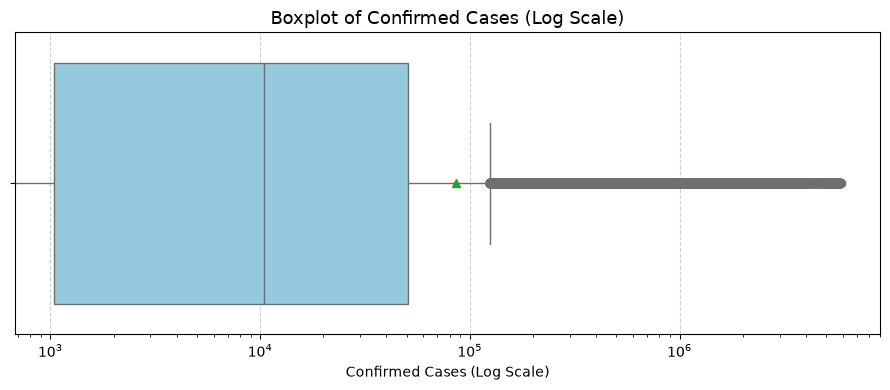

In [ ]:
plt.figure(figsize=(9, 4))
sns.boxplot(x=df["Confirmed"], color="skyblue", showmeans=True)
plt.xscale("log")
plt.title("Boxplot of Confirmed Cases (Log Scale)", fontsize=13)
plt.xlabel("Confirmed Cases (Log Scale)")
plt.grid(axis="x", linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()

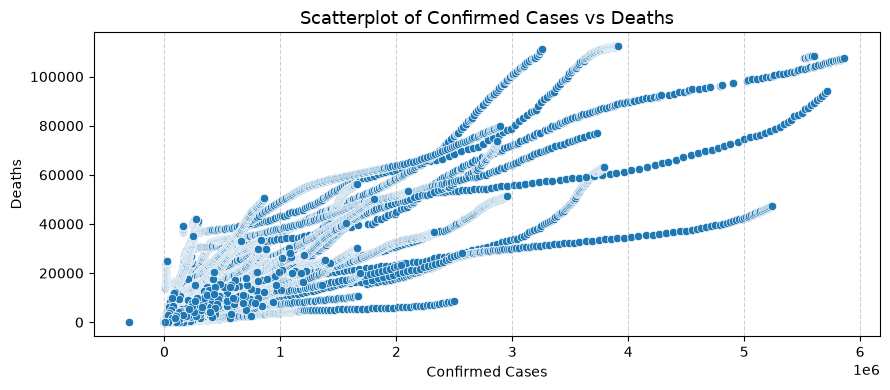

In [25]:
plt.figure(figsize=(9, 4))
sns.scatterplot(x=df["Confirmed"],y=df["Deaths"])
plt.title("Scatterplot of Confirmed Cases vs Deaths", fontsize=13)
plt.xlabel("Confirmed Cases")
plt.ylabel("Deaths")
plt.grid(axis="x", linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()

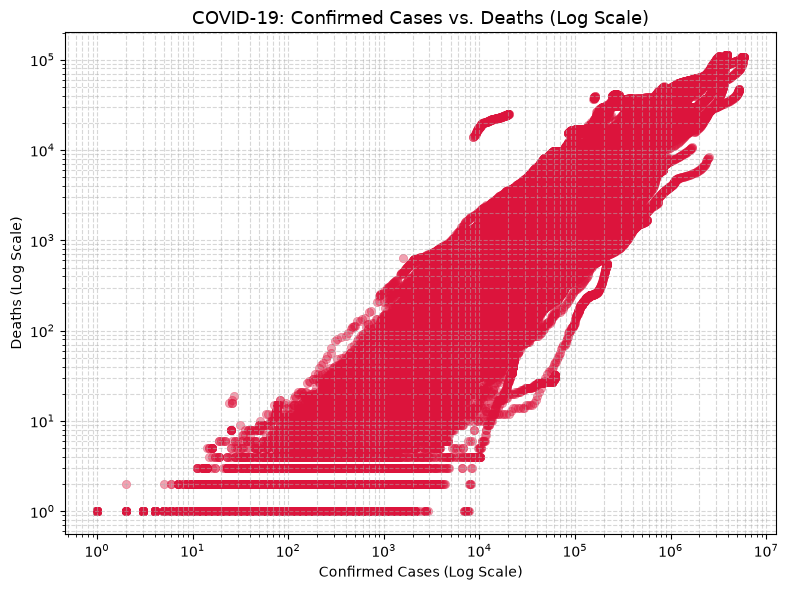

In [26]:
plot_data = df[(df["Confirmed"] > 0) & (df["Deaths"] > 0)]
plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=plot_data,
    x="Confirmed",
    y="Deaths",
    alpha=0.4,       # Transparency prevents dense clusters from blinding the plot
    color="crimson",
    edgecolor=None
)
# Apply log scale to both axes
plt.xscale("log")
plt.yscale("log")
plt.title("COVID-19: Confirmed Cases vs. Deaths (Log Scale)", fontsize=13)
plt.xlabel("Confirmed Cases (Log Scale)")
plt.ylabel("Deaths (Log Scale)")
plt.grid(True, which="both", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

/var/folders/nc/6_1vctrx2z73rhr1y8qh9yw40000gn/T/ipykernel_2785/1669557249.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_top, x="Country/Region", y="Confirmed", palette="Set3")


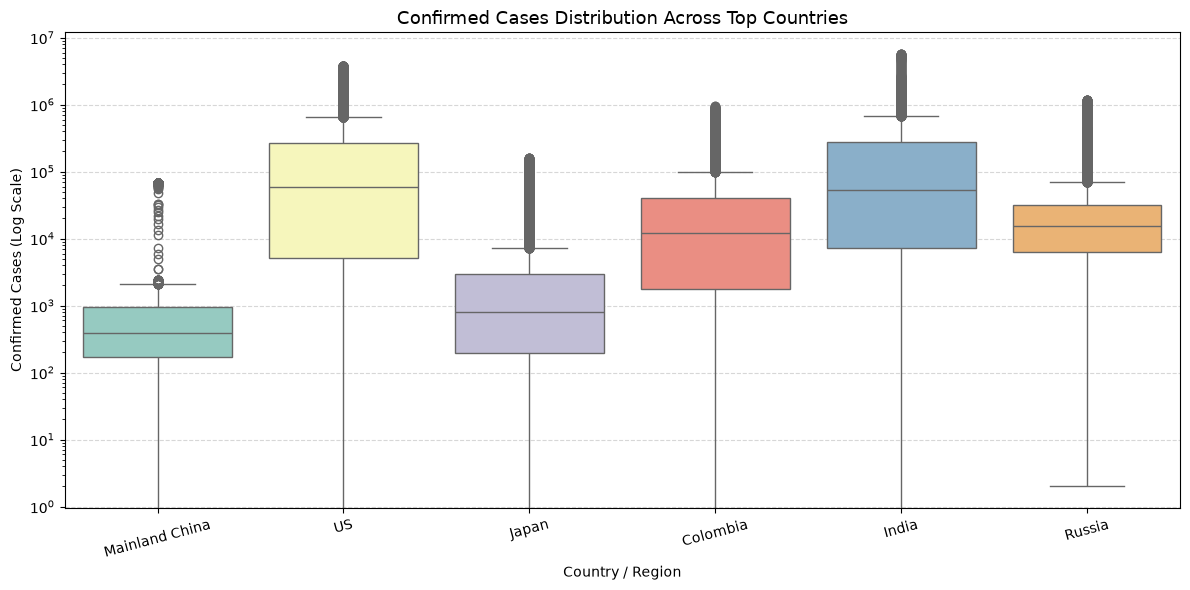

In [27]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

df = pd.read_csv("covid_19_data.csv")

# Pick top 6 countries with the most reported records
top_countries = df["Country/Region"].value_counts().nlargest(6).index
df_top = df[df["Country/Region"].isin(top_countries)]

plt.figure(figsize=(12, 6))
sns.boxplot(data=df_top, x="Country/Region", y="Confirmed", palette="Set3")
plt.yscale("log")
plt.title("Confirmed Cases Distribution Across Top Countries", fontsize=13)
plt.xlabel("Country / Region")
plt.ylabel("Confirmed Cases (Log Scale)")
plt.xticks(rotation=15)
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

In [ ]:
print("hello")